# Phase 6 — Recommendation Engine

This notebook demonstrates the AgroOpt Recommendation Engine: given a farm's
local conditions (climate, soil, management practices), it:

1. **Predicts** crop yield (hg/ha) for each of the four crops using the saved Ridge pipeline.
2. **Ranks** crops from highest to lowest predicted yield.
3. **Optimises** management inputs (fertilizer, irrigation, growing season length)
   to maximise yield for the recommended crop.

**No retraining occurs** — the engine loads `models/best_model.pkl` and applies
the same feature-engineering logic used during training.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Add project root to path
ROOT = Path("__file__").resolve().parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.logging import setup_logging
from src.recommendation.engine import (
    FarmConditions,
    load_assets,
    predict_yield,
    recommend_crop,
    optimize_conditions,
    CROPS,
    REGIONS,
    SOIL_TYPES,
    WEATHER_CONDITIONS,
    CROP_OPTIMAL_RAINFALL_MM,
    CROP_MAX_TEMP_C,
)

setup_logging()
print("Engine loaded.")

2026-03-06 07:44:57 | INFO     | src.utils.logging:65 — Logging initialised — level=INFO, file=C:\Users\shahu\Documents\OneDrive\OPEN CLASSROOMS\PROJET 12\Agro_Opt\logs\app.log


Engine loaded.


In [2]:
# Load model pipeline, feature names, and FAO reference values
assets = load_assets()
print(f"Model type    : {type(assets['model']).__name__}")
print(f"Features      : {len(assets['feature_cols'])}")
print(f"FAO rainfall  : {assets['fao_refs']['fao_rainfall_mm']:.1f} mm")
print(f"FAO avg temp  : {assets['fao_refs']['fao_avg_temp']:.2f} °C")
print()
print("FAO 2013 USA reference yields (hg/ha):")
for crop, val in assets['fao_refs']['fao_yield_hg_ha'].items():
    print(f"  {crop:<10s}: {val:>10,.0f} hg/ha  ({val/10_000:.2f} t/ha)")

2026-03-06 07:45:01 | INFO     | src.recommendation.engine:157 — Loaded model from C:\Users\shahu\Documents\OneDrive\OPEN CLASSROOMS\PROJET 12\Agro_Opt\models\best_model.pkl


2026-03-06 07:45:01 | INFO     | src.recommendation.engine:163 — Loaded 36 feature names


2026-03-06 07:45:03 | INFO     | src.recommendation.engine:199 — FAO 2013 USA refs — rainfall: 715.0 mm, avg_temp: 16.44 °C


Model type    : Pipeline
Features      : 36
FAO rainfall  : 715.0 mm
FAO avg temp  : 16.44 °C

FAO 2013 USA reference yields (hg/ha):
  Maize     :     99,256 hg/ha  (9.93 t/ha)
  Rice      :     86,232 hg/ha  (8.62 t/ha)
  Soybean   :     29,615 hg/ha  (2.96 t/ha)
  Wheat     :     31,673 hg/ha  (3.17 t/ha)


## 2. Single Yield Prediction

Predict yield for a Midwest-style farm: warm season, moderate rainfall, loam soil.

In [3]:
# Define baseline farm conditions
farm_a = FarmConditions(
    rainfall_mm=650.0,
    temperature_celsius=22.0,
    days_to_harvest=120,
    region="East",
    soil_type="Loam",
    weather_condition="Sunny",
    fertilizer_used=True,
    irrigation_used=True,
)

print("Farm A — Midwest-style conditions")
print(f"  Rainfall      : {farm_a.rainfall_mm} mm")
print(f"  Temperature   : {farm_a.temperature_celsius} °C")
print(f"  Days to harvest: {farm_a.days_to_harvest}")
print(f"  Region        : {farm_a.region}")
print(f"  Soil type     : {farm_a.soil_type}")
print(f"  Weather       : {farm_a.weather_condition}")
print(f"  Fertilizer    : {farm_a.fertilizer_used}")
print(f"  Irrigation    : {farm_a.irrigation_used}")
print()

# Predict for each crop individually
print("Individual yield predictions:")
for crop in CROPS:
    y = predict_yield(farm_a, crop, assets)
    print(f"  {crop:<10s}: {y:>10,.1f} hg/ha  ({y/10_000:.3f} t/ha)")

Farm A — Midwest-style conditions
  Rainfall      : 650.0 mm
  Temperature   : 22.0 °C
  Days to harvest: 120
  Region        : East
  Soil type     : Loam
  Weather       : Sunny
  Fertilizer    : True
  Irrigation    : True

Individual yield predictions:
  Maize     :   63,886.1 hg/ha  (6.389 t/ha)
  Rice      :   63,911.0 hg/ha  (6.391 t/ha)
  Soybean   :   63,904.2 hg/ha  (6.390 t/ha)
  Wheat     :   63,886.7 hg/ha  (6.389 t/ha)


## 3. Crop Recommendation

Rank all four crops and highlight the top recommendation.

In [4]:
recs = recommend_crop(farm_a, assets)

df_recs = pd.DataFrame(recs).set_index("rank")
df_recs["predicted_yield_t_ha"] = df_recs["predicted_yield_t_ha"]
df_recs["fao_benchmark_t_ha"] = (df_recs["fao_benchmark_hg_ha"] / 10_000).round(3)
df_recs["vs_fao_%"] = (
    (df_recs["predicted_yield_hg_ha"] - df_recs["fao_benchmark_hg_ha"])
    / df_recs["fao_benchmark_hg_ha"] * 100
).round(1)

display_cols = [
    "crop", "predicted_yield_t_ha", "fao_benchmark_t_ha",
    "vs_fao_%", "water_stress", "heat_stress"
]
df_recs[display_cols].style \
    .format({
        "predicted_yield_t_ha": "{:.3f}",
        "fao_benchmark_t_ha":   "{:.3f}",
        "vs_fao_%":             "{:+.1f}%",
        "water_stress":         "{:.3f}",
        "heat_stress":          "{:.1f}",
    }) \
    .background_gradient(subset=["predicted_yield_t_ha"], cmap="Greens") \
    .set_caption("Crop Recommendation — Farm A (ranked by predicted yield)")

,crop,predicted_yield_t_ha,fao_benchmark_t_ha,vs_fao_%,water_stress,heat_stress
rank,,,,,,
1,Rice,6.391,8.623,-25.9%,0.458,0.0
2,Soybean,6.390,2.962,+115.8%,0.083,0.0
3,Wheat,6.389,3.167,+101.7%,0.300,0.0
4,Maize,6.389,9.926,-35.6%,0.000,0.0


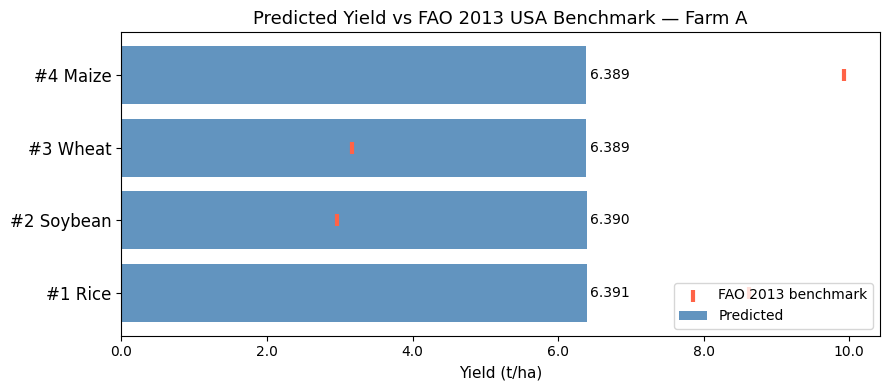


Top recommendation: Rice @ 6.391 t/ha


In [5]:
# Horizontal bar chart — predicted yield vs FAO benchmark
fig, ax = plt.subplots(figsize=(9, 4))

crops_ordered = [r["crop"] for r in recs]
yields_t = [r["predicted_yield_t_ha"] for r in recs]
fao_t = [r["fao_benchmark_hg_ha"] / 10_000 for r in recs]

y_pos = np.arange(len(crops_ordered))
bars = ax.barh(y_pos, yields_t, color="steelblue", alpha=0.85, label="Predicted")
ax.scatter(fao_t, y_pos, color="tomato", zorder=5, s=80, marker="|",
           linewidths=3, label="FAO 2013 benchmark")

ax.set_yticks(y_pos)
ax.set_yticklabels([f"#{i+1} {c}" for i, c in enumerate(crops_ordered)], fontsize=12)
ax.set_xlabel("Yield (t/ha)", fontsize=11)
ax.set_title("Predicted Yield vs FAO 2013 USA Benchmark — Farm A", fontsize=13)
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

for bar, y in zip(bars, yields_t):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{y:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/06_crop_recommendation_farm_a.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nTop recommendation: {recs[0]['crop']} @ {recs[0]['predicted_yield_t_ha']:.3f} t/ha")

## 4. Condition Optimisation

Grid-search over management inputs (fertilizer on/off, irrigation on/off, days 60–200)
to find the best configuration for the top-ranked crop.

In [6]:
best_crop = recs[0]["crop"]
opt = optimize_conditions(farm_a, best_crop, assets)

bc = opt["best_conditions"]
print(f"Crop          : {opt['crop']}")
print(f"Baseline yield: {opt['baseline_yield_t_ha']:.3f} t/ha")
print(f"Optimal yield : {opt['best_yield_t_ha']:.3f} t/ha")
print(f"Yield gain    : +{opt['yield_gain_hg_ha']:,.0f} hg/ha  (+{opt['yield_gain_pct']:.1f}%)")
print()
print("Optimal management inputs:")
print(f"  Fertilizer  : {bc.fertilizer_used}")
print(f"  Irrigation  : {bc.irrigation_used}")
print(f"  Days to harvest: {bc.days_to_harvest}")

Crop          : Rice
Baseline yield: 6.391 t/ha
Optimal yield : 6.391 t/ha
Yield gain    : +1 hg/ha  (+0.0%)

Optimal management inputs:
  Fertilizer  : True
  Irrigation  : True
  Days to harvest: 100


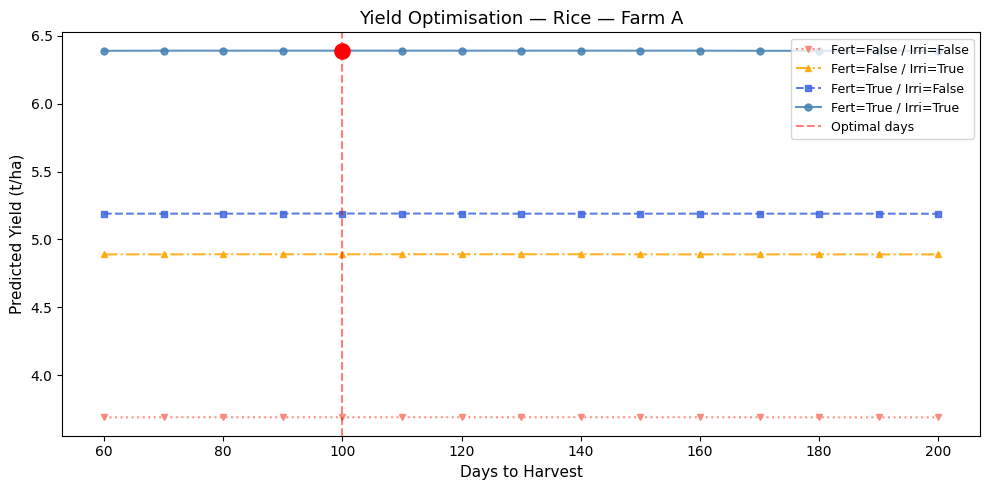

In [7]:
# Plot yield vs days_to_harvest for each management combination
grid_df = pd.DataFrame(opt["grid_results"])
grid_df["config"] = (
    "Fert=" + grid_df["fertilizer_used"].astype(str) +
    " / Irri=" + grid_df["irrigation_used"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Fert=True / Irri=True": "steelblue",
          "Fert=True / Irri=False": "royalblue",
          "Fert=False / Irri=True": "orange",
          "Fert=False / Irri=False": "salmon"}
styles = {"Fert=True / Irri=True": "-o",
          "Fert=True / Irri=False": "--s",
          "Fert=False / Irri=True": "-.^",
          "Fert=False / Irri=False": ":v"}

for cfg, grp in grid_df.groupby("config"):
    grp = grp.sort_values("days_to_harvest")
    ax.plot(grp["days_to_harvest"], grp["predicted_yield_t_ha"],
            styles.get(cfg, "-"), color=colors.get(cfg, "gray"),
            label=cfg, alpha=0.85, markersize=5)

# Mark optimum
ax.axvline(bc.days_to_harvest, color="red", linestyle="--", alpha=0.5, label="Optimal days")
ax.scatter([bc.days_to_harvest], [opt["best_yield_t_ha"]], color="red", s=120, zorder=5)

ax.set_xlabel("Days to Harvest", fontsize=11)
ax.set_ylabel("Predicted Yield (t/ha)", fontsize=11)
ax.set_title(f"Yield Optimisation — {best_crop} — Farm A", fontsize=13)
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.savefig("../reports/figures/06_optimization_farm_a.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Multi-Scenario Comparison

Compare recommendations across three contrasting farm scenarios.

In [8]:
scenarios = {
    "Midwest (warm, loam)": FarmConditions(
        rainfall_mm=650, temperature_celsius=22, days_to_harvest=120,
        region="East", soil_type="Loam", weather_condition="Sunny",
        fertilizer_used=True, irrigation_used=True
    ),
    "Arid South (hot, sandy)": FarmConditions(
        rainfall_mm=250, temperature_celsius=34, days_to_harvest=100,
        region="South", soil_type="Sandy", weather_condition="Sunny",
        fertilizer_used=True, irrigation_used=True
    ),
    "Rainy North (cool, clay)": FarmConditions(
        rainfall_mm=1100, temperature_celsius=14, days_to_harvest=150,
        region="North", soil_type="Clay", weather_condition="Rainy",
        fertilizer_used=False, irrigation_used=False
    ),
}

scenario_results = {}
for name, farm in scenarios.items():
    recs_s = recommend_crop(farm, assets)
    scenario_results[name] = recs_s
    top = recs_s[0]
    print(f"{name}")
    print(f"  -> Best crop : {top['crop']}  ({top['predicted_yield_t_ha']:.3f} t/ha)")
    for r in recs_s:
        print(f"     #{r['rank']} {r['crop']:<10s} {r['predicted_yield_t_ha']:.3f} t/ha")
    print()

Midwest (warm, loam)
  -> Best crop : Rice  (6.391 t/ha)
     #1 Rice       6.391 t/ha
     #2 Soybean    6.390 t/ha
     #3 Wheat      6.389 t/ha
     #4 Maize      6.389 t/ha

Arid South (hot, sandy)
  -> Best crop : Rice  (4.627 t/ha)
     #1 Rice       4.627 t/ha
     #2 Soybean    4.626 t/ha
     #3 Wheat      4.625 t/ha
     #4 Maize      4.624 t/ha

Rainy North (cool, clay)
  -> Best crop : Rice  (5.782 t/ha)
     #1 Rice       5.782 t/ha
     #2 Soybean    5.780 t/ha
     #3 Wheat      5.778 t/ha
     #4 Maize      5.778 t/ha



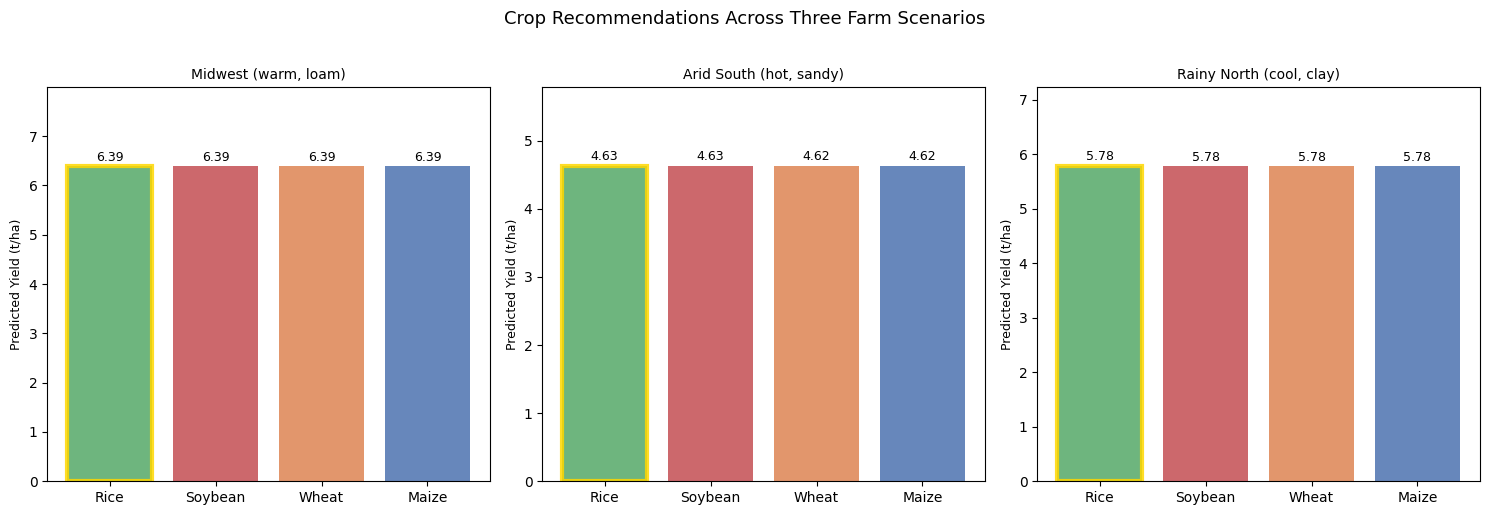

In [9]:
# Grouped bar chart: all scenarios × all crops
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

scenario_names = list(scenarios.keys())
crop_colors = {"Maize": "#4C72B0", "Rice": "#55A868", "Soybean": "#C44E52", "Wheat": "#DD8452"}

for ax, (name, recs_s) in zip(axes, scenario_results.items()):
    crops_s = [r["crop"] for r in recs_s]
    yields_s = [r["predicted_yield_t_ha"] for r in recs_s]
    colors_s = [crop_colors[c] for c in crops_s]

    bars = ax.bar(crops_s, yields_s, color=colors_s, alpha=0.85)
    for bar, y in zip(bars, yields_s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"{y:.2f}", ha="center", va="bottom", fontsize=9)

    # Crown mark on best crop
    ax.get_children()[0].set_edgecolor("gold")
    ax.get_children()[0].set_linewidth(3)

    ax.set_title(name, fontsize=10)
    ax.set_ylabel("Predicted Yield (t/ha)", fontsize=9)
    ax.set_ylim(0, max(yields_s) * 1.25)

plt.suptitle("Crop Recommendations Across Three Farm Scenarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/06_multi_scenario_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Sensitivity Analysis — Rainfall Effect on Yield

How does predicted yield vary with rainfall for each crop, all else constant?

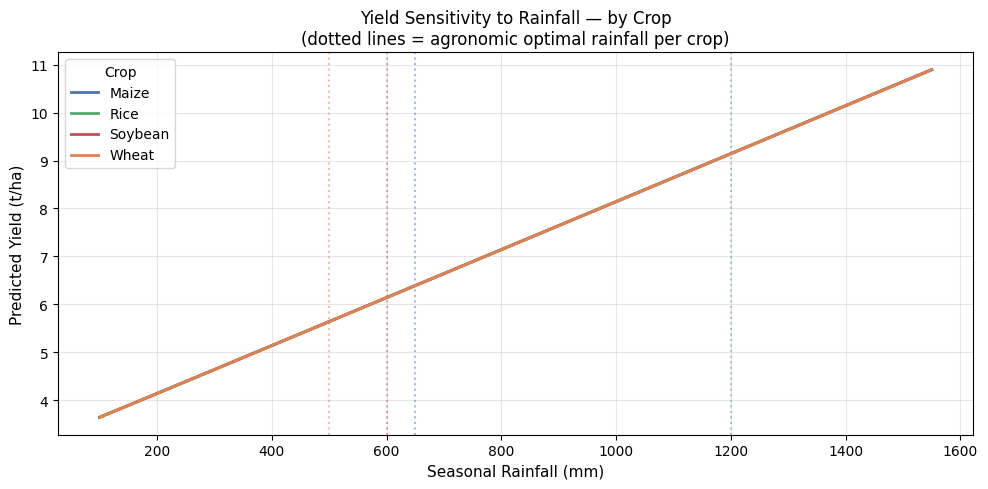

In [10]:
rainfall_range = np.arange(100, 1600, 50)
base_conditions = dict(
    temperature_celsius=22.0,
    days_to_harvest=120,
    region="East",
    soil_type="Loam",
    weather_condition="Sunny",
    fertilizer_used=True,
    irrigation_used=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

for crop, color in crop_colors.items():
    yields = []
    for rain in rainfall_range:
        farm = FarmConditions(rainfall_mm=float(rain), **base_conditions)
        y = predict_yield(farm, crop, assets)
        yields.append(y / 10_000)  # to t/ha
    ax.plot(rainfall_range, yields, label=crop, color=color, linewidth=2)

    # Mark optimal rainfall for each crop
    opt_r = CROP_OPTIMAL_RAINFALL_MM[crop]
    ax.axvline(opt_r, color=color, linestyle=":", alpha=0.5)

ax.set_xlabel("Seasonal Rainfall (mm)", fontsize=11)
ax.set_ylabel("Predicted Yield (t/ha)", fontsize=11)
ax.set_title("Yield Sensitivity to Rainfall — by Crop\n(dotted lines = agronomic optimal rainfall per crop)",
             fontsize=12)
ax.legend(title="Crop", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/06_rainfall_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Sensitivity Analysis — Temperature Effect on Yield

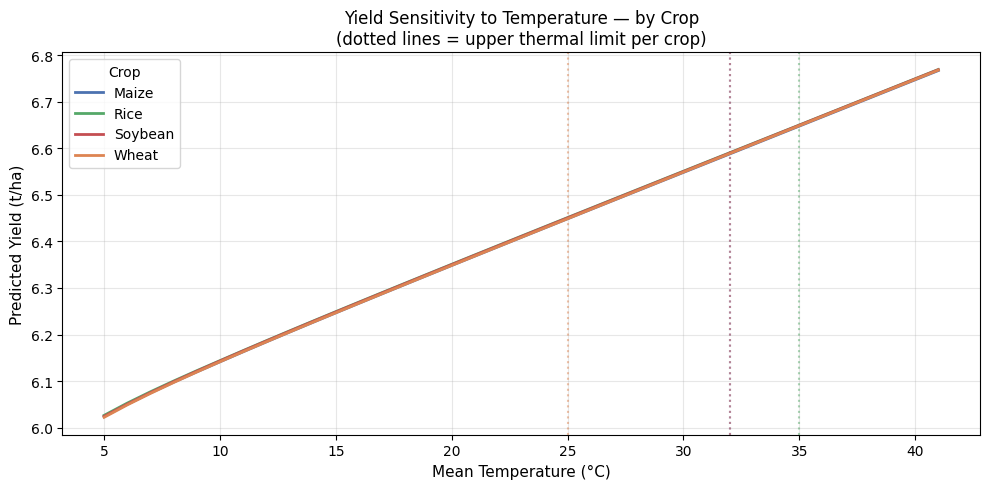

In [11]:
temp_range = np.arange(5, 42, 1)
base_conditions_temp = dict(
    rainfall_mm=650.0,
    days_to_harvest=120,
    region="East",
    soil_type="Loam",
    weather_condition="Sunny",
    fertilizer_used=True,
    irrigation_used=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

for crop, color in crop_colors.items():
    yields = []
    for temp in temp_range:
        farm = FarmConditions(temperature_celsius=float(temp), **base_conditions_temp)
        y = predict_yield(farm, crop, assets)
        yields.append(y / 10_000)
    ax.plot(temp_range, yields, label=crop, color=color, linewidth=2)

    # Mark upper thermal limit
    t_max = CROP_MAX_TEMP_C[crop]
    ax.axvline(t_max, color=color, linestyle=":", alpha=0.5)

ax.set_xlabel("Mean Temperature (°C)", fontsize=11)
ax.set_ylabel("Predicted Yield (t/ha)", fontsize=11)
ax.set_title("Yield Sensitivity to Temperature — by Crop\n(dotted lines = upper thermal limit per crop)",
             fontsize=12)
ax.legend(title="Crop", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/06_temperature_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Summary

In [12]:
from src.models.evaluate import compute_metrics
import json

with open("../models/model_results.json") as f:
    model_results = json.load(f)

best = model_results["best_model"]
m = model_results["models"][best]

print("=" * 65)
print("PHASE 6 — RECOMMENDATION ENGINE  SUMMARY")
print("=" * 65)
print()
print(f"Model backend   : Ridge (R²={m['test_r2']:.4f}, RMSE={m['test_rmse']:,.0f} hg/ha)")
print(f"Features        : {len(assets['feature_cols'])}")
print(f"Crops supported : {', '.join(CROPS)}")
print(f"Regions         : {', '.join(REGIONS)}")
print(f"Soil types      : {', '.join(SOIL_TYPES)}")
print()
print("Public API")
print("  load_assets()                              — load model + references")
print("  predict_yield(conditions, crop, assets)    — single crop prediction (hg/ha)")
print("  recommend_crop(conditions, assets)         — ranked list for all 4 crops")
print("  optimize_conditions(conditions, crop, assets) — grid search over management inputs")
print()
print("Saved figures:")
for fig_name in [
    "06_crop_recommendation_farm_a.png",
    "06_optimization_farm_a.png",
    "06_multi_scenario_comparison.png",
    "06_rainfall_sensitivity.png",
    "06_temperature_sensitivity.png",
]:
    print(f"  reports/figures/{fig_name}")
print()
print("Phase 6 complete.")

PHASE 6 — RECOMMENDATION ENGINE  SUMMARY

Model backend   : Ridge (R²=0.9130, RMSE=4,989 hg/ha)
Features        : 36
Crops supported : Maize, Rice, Soybean, Wheat
Regions         : East, North, South, West
Soil types      : Chalky, Clay, Loam, Peaty, Sandy, Silt

Public API
  load_assets()                              — load model + references
  predict_yield(conditions, crop, assets)    — single crop prediction (hg/ha)
  recommend_crop(conditions, assets)         — ranked list for all 4 crops
  optimize_conditions(conditions, crop, assets) — grid search over management inputs

Saved figures:
  reports/figures/06_crop_recommendation_farm_a.png
  reports/figures/06_optimization_farm_a.png
  reports/figures/06_multi_scenario_comparison.png
  reports/figures/06_rainfall_sensitivity.png
  reports/figures/06_temperature_sensitivity.png

Phase 6 complete.
